# Zadanie dodatkowe

## Importy

In [1]:
import os

from google.colab import userdata
kaggle_api_token = userdata.get('kaggle_api_token')
os.environ['KAGGLE_USERNAME'] = "michawilczkowski"
os.environ['KAGGLE_KEY'] = kaggle_api_token

In [2]:
from datasets import load_dataset, concatenate_datasets
import kaggle
from kagglehub import dataset_download
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Eksploracja danych

In [3]:
path = dataset_download("julinmaloof/the-oxfordiiit-pet-dataset")

Using Colab cache for faster access to the 'the-oxfordiiit-pet-dataset' dataset.


In [4]:
print(os.listdir(path + '/annotations/trimaps'))
print(os.listdir(path + '/images/'))

['staffordshire_bull_terrier_171.png', 'Maine_Coon_271.png', 'pug_37.png', 'scottish_terrier_74.png', 'Persian_21.png', 'pug_127.png', 'staffordshire_bull_terrier_15.png', 'english_cocker_spaniel_88.png', 'Egyptian_Mau_86.png', 'British_Shorthair_32.png', 'havanese_89.png', 'japanese_chin_82.png', 'Bombay_163.png', 'Maine_Coon_168.png', 'Egyptian_Mau_79.png', 'staffordshire_bull_terrier_119.png', 'British_Shorthair_70.png', 'american_bulldog_168.png', 'newfoundland_168.png', 'British_Shorthair_159.png', 'keeshond_91.png', 'yorkshire_terrier_180.png', 'newfoundland_23.png', 'Siamese_173.png', 'Ragdoll_188.png', 'german_shorthaired_115.png', 'Bengal_196.png', 'Bombay_130.png', 'basset_hound_32.png', 'american_bulldog_174.png', 'Persian_164.png', 'Bombay_59.png', 'boxer_177.png', 'staffordshire_bull_terrier_11.png', 'scottish_terrier_160.png', 'Birman_107.png', 'yorkshire_terrier_107.png', 'basset_hound_15.png', 'leonberger_13.png', 'beagle_126.png', 'British_Shorthair_272.png', 'yorkshir

In [5]:
print('Liczba probek w zbiorze zdjec:', len(os.listdir(path + '/images/')))
print('Liczba probek w zbiorze masek:', len(os.listdir(path + '/annotations/trimaps/')))
print('Liczba plikow .mat:', sum([int('mat' in x) for x in os.listdir(path + '/images/')]))
#W zdjecjach sa trzy pliki z rozszerzeniem .mat, ktore bede ignorowal

Liczba probek w zbiorze zdjec: 7393
Liczba probek w zbiorze masek: 7390
Liczba plikow .mat: 3


In [6]:
[Image.open(path + '/images/' + img).size for img in os.listdir(path + '/images/')[:5]]
# Obrazy sa roznej wielkosci

[(500, 333), (500, 375), (500, 333), (325, 500), (500, 336)]

In [7]:
mask = Image.open(path + '/annotations/trimaps/staffordshire_bull_terrier_171.png')
img = Image.open(path + '/images/staffordshire_bull_terrier_171.jpg')
print("Rozmiar zdjecia: ", img.size)
print("Rozmiar maski:", mask.size)
print("Wartosci w masce:", np.unique(np.array(mask)))

Rozmiar zdjecia:  (500, 375)
Rozmiar maski: (500, 375)
Wartosci w masce: [1 2 3]


array([[150, 100, 100, ..., 100, 100, 100],
       [150, 100, 100, ..., 100, 100, 100],
       [150, 100, 100, ..., 100, 100, 100],
       ...,
       [100, 100, 100, ..., 100, 100, 100],
       [100, 100, 100, ..., 100, 100, 100],
       [100, 100, 100, ..., 100, 100, 100]], dtype=uint8)
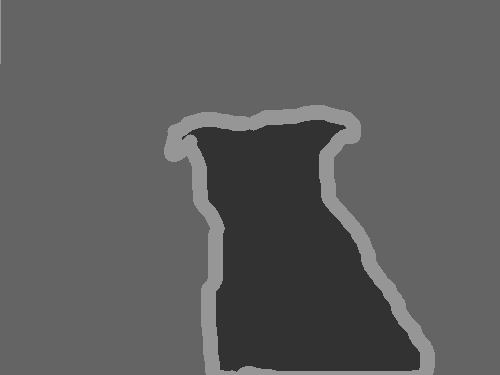

In [8]:
np.array(mask) * 50

1 = zwierze

2 = tlo

3 = granica

In [9]:
all_images_names = [name[:-4] for name in os.listdir(path + '/annotations/trimaps')]

In [10]:
all_masks = [np.array(Image.open(path + '/annotations/trimaps/' + mask + '.png')) for mask in all_images_names]

In [11]:
mask_coverage = [np.sum(mask != 1) / (mask.shape[0] * mask.shape[1]) for mask in all_masks]

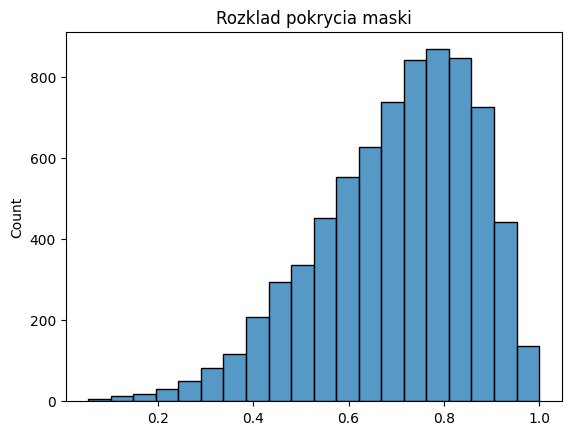

In [12]:
sns.histplot(mask_coverage, bins=20)
plt.title('Rozklad pokrycia maski')
plt.show()

In [13]:
all_images = [np.array(Image.open(path + '/images/' + image + '.jpg')) for image in all_images_names]

In [14]:
mean_brightness = [np.mean(img) for img in all_images]

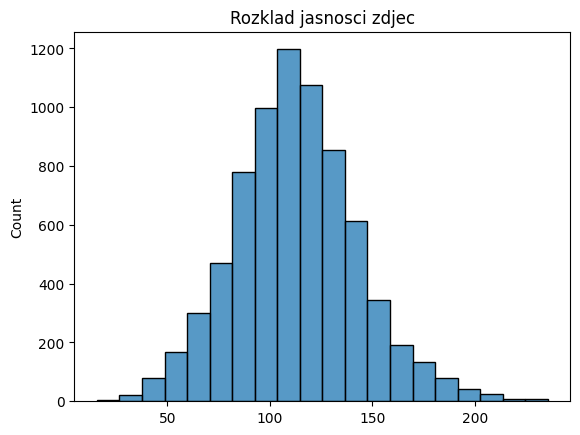

In [15]:
sns.histplot(mean_brightness, bins=20)
plt.title('Rozklad jasnosci zdjec')
plt.show()

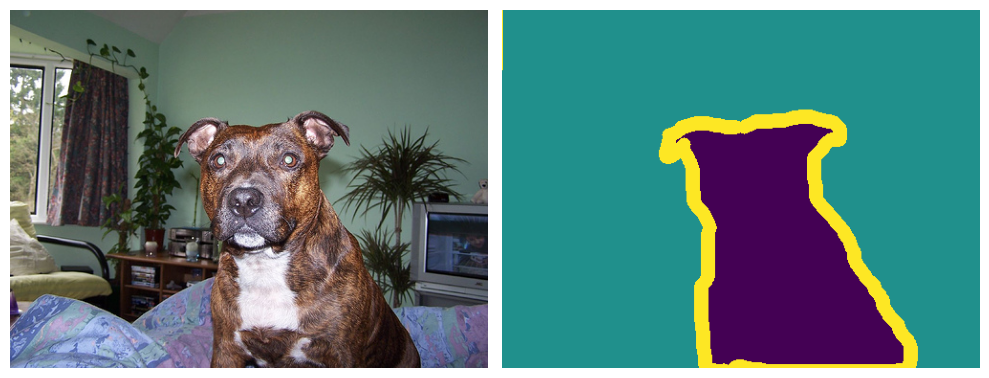

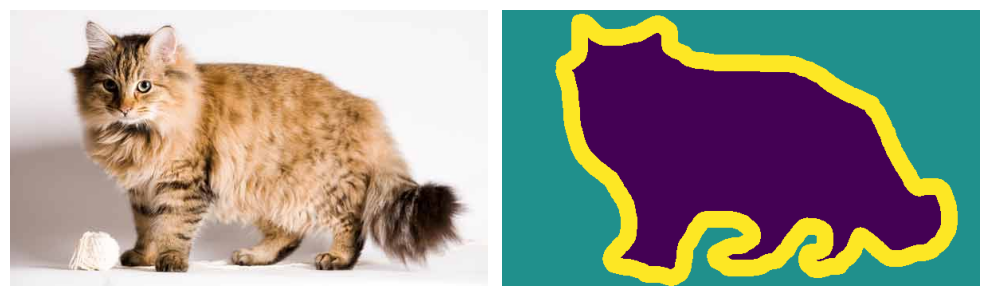

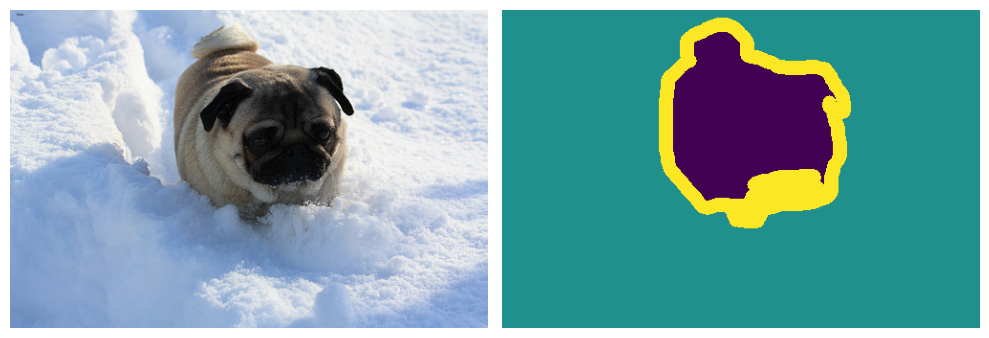

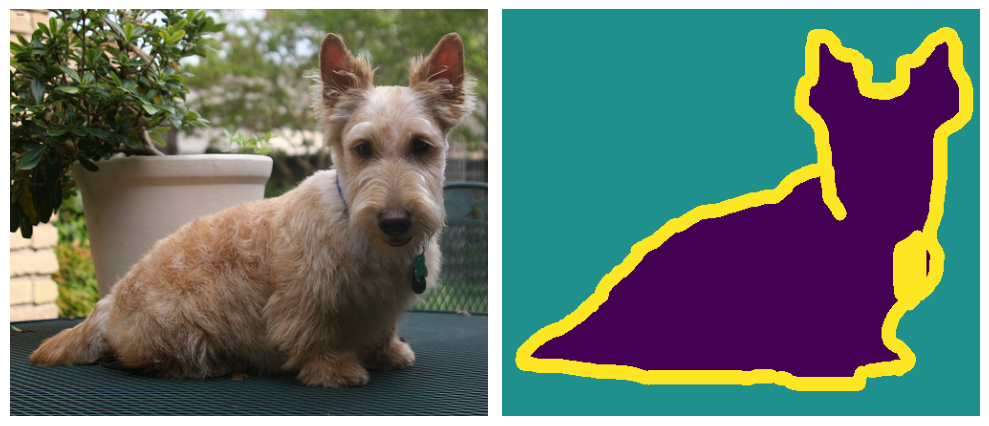

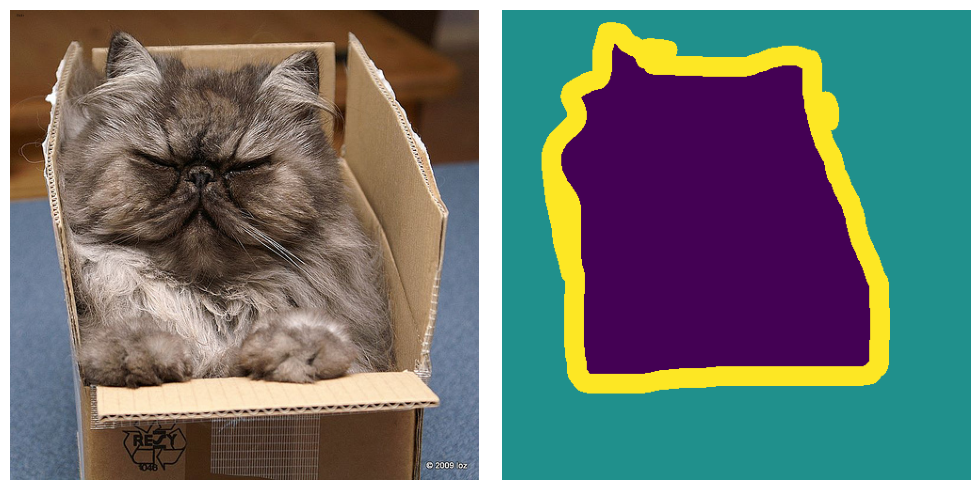

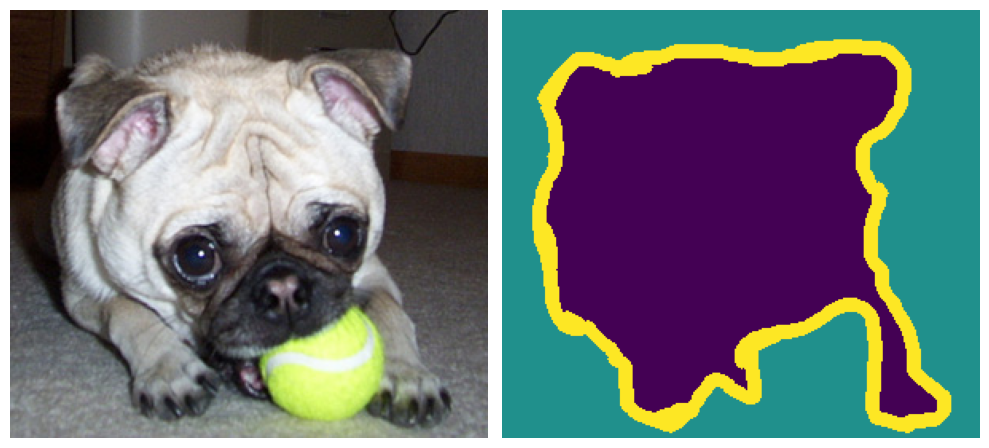

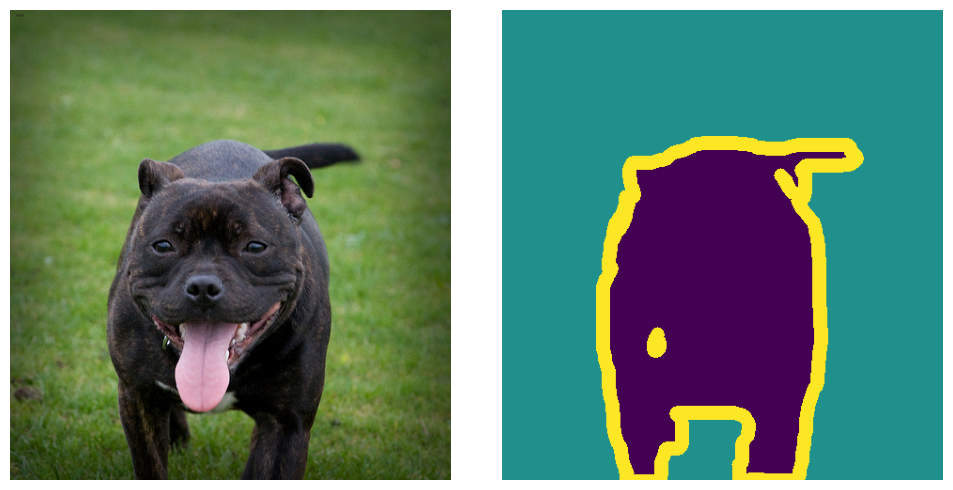

In [16]:
for i in range(7):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(all_images[i])
    axes[0].axis('off')
    axes[1].imshow(all_masks[i])
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()